# Prediksi Harga Beras, Cabai Rawit, dan Bawang Merah di Provinsi DI Yogyakarta

Prediksi harga harian dengan LightGBM; hyperparameter dicari pakai Genetic Algorithm.


## 1. Import Library

Import library data, visualisasi, uji stasioner, LightGBM, skforecast, dan PyGAD.


In [85]:
import joblib as jl
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import pygad
import seaborn as sns
from feature_engine.timeseries.forecasting import LagFeatures, WindowFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    root_mean_squared_error,
)
from sklearn.model_selection import KFold
from statsmodels.tsa.seasonal import MSTL
from statsmodels.tsa.stattools import adfuller
import missingno as mgno
from skforecast.recursive import ForecasterRecursive
from skforecast.direct import ForecasterDirect
from skforecast.preprocessing import RollingFeatures
from skforecast.preprocessing import CalendarFeatures
from skforecast.utils import save_forecaster
from sktime.forecasting.trend import TrendForecaster
from sktime.split.temporal_train_test_split import TemporalTrainTestSplitter
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

## 2. Exploratory Data Analysis (EDA)

Cek struktur, sebaran, korelasi, dan missing value sebelum dibersihkan.


### 2.1 Memuat Dataset (CSV)

Membaca `DATASET-BERAS.csv` ke dalam `df_raw`.


In [54]:
df_raw = pd.read_csv("DATASET-BERAS.csv")
df_raw.head()

,tanggal,Beras Kualitas Bawah I,Beras Kualitas Bawah II,Beras Kualitas Medium I,Beras Kualitas Medium II,Beras Kualitas Super I,Beras Kualitas Super II,Bawang Merah Ukuran Sedang,Cabai Rawit Hijau,Cabai Rawit Merah
0,2021-01-04,10.4,9.9,11.75,11.0,12.75,12.4,32.25,56.25,62.50
1,2021-01-05,10.4,9.9,11.75,11.0,12.75,12.4,31.75,56.25,68.75
2,2021-01-06,10.4,9.9,11.75,11.0,12.75,12.4,31.75,56.25,68.75
3,2021-01-07,10.4,9.9,11.75,11.0,12.75,12.4,31.75,56.00,71.25
4,2021-01-08,10.4,9.9,11.75,11.0,12.75,12.4,31.75,56.00,71.25


### 2.2 Mengubah dan Menetapkan Indeks Tanggal

Kolom `tanggal` jadi datetime index harian (`asfreq("D")`).


In [55]:
df_raw.index = pd.DatetimeIndex(df_raw["tanggal"], yearfirst=True)
df_raw.drop(columns=["tanggal"], inplace=True)
df_raw = df_raw.asfreq("D")

### 2.3 Memeriksa Informasi dan Tipe Data

Cek dimensi, tipe data, dan jumlah non-null tiap kolom.


In [56]:
df_raw.shape
df_raw.info()
df_raw.dtypes

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2038 entries, 2021-01-04 to 2026-08-03
Freq: D
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Beras Kualitas Bawah I      1427 non-null   float64
 1   Beras Kualitas Bawah II     1427 non-null   float64
 2   Beras Kualitas Medium I     1427 non-null   float64
 3   Beras Kualitas Medium II    1427 non-null   float64
 4   Beras Kualitas Super I      1427 non-null   float64
 5   Beras Kualitas Super II     1427 non-null   float64
 6   Bawang Merah Ukuran Sedang  1427 non-null   float64
 7   Cabai Rawit Hijau           1427 non-null   float64
 8   Cabai Rawit Merah           1427 non-null   float64
dtypes: float64(9)
memory usage: 159.2 KB


Beras Kualitas Bawah I        float64
Beras Kualitas Bawah II       float64
Beras Kualitas Medium I       float64
Beras Kualitas Medium II      float64
Beras Kualitas Super I        float64
Beras Kualitas Super II       float64
Bawang Merah Ukuran Sedang    float64
Cabai Rawit Hijau             float64
Cabai Rawit Merah             float64
dtype: object

### 2.4 Visualisasi Distribusi dan Outlier (Boxplot)

Boxplot harga tiap komoditas untuk lihat sebaran dan outlier.


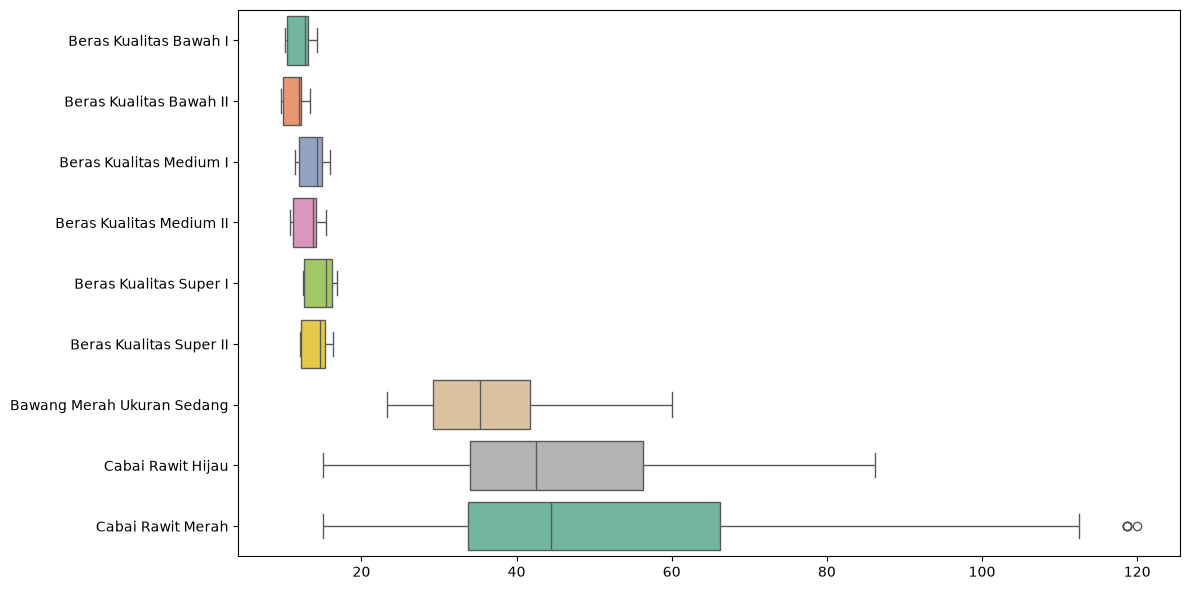

In [57]:
nums_cols = df_raw.select_dtypes(include="number").columns

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_raw[nums_cols], orient="h", palette="Set2", showfliers=True, whis=1.5
)
plt.tight_layout()
plt.show()

### 2.5 Matriks Korelasi

Heatmap korelasi antar harga komoditas.


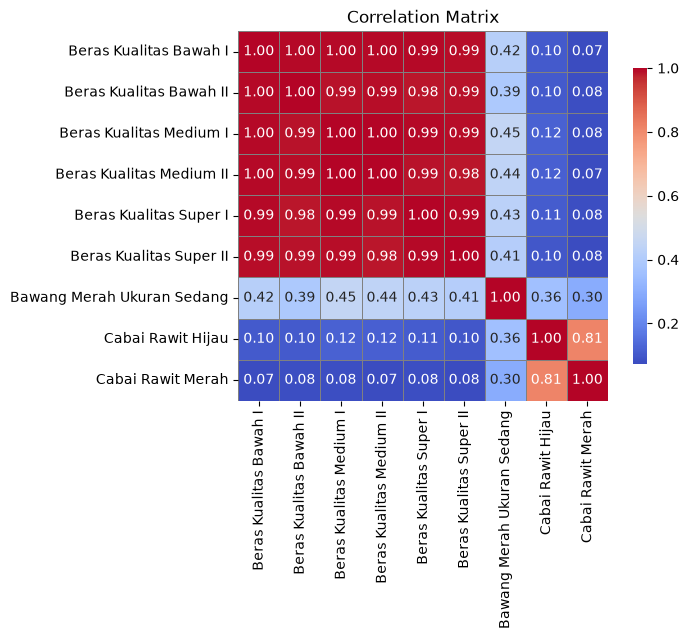

In [58]:
matrix_corr = df_raw[nums_cols].corr()
sns.heatmap(
    matrix_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True,
    cbar_kws={"shrink": 0.8},
    linewidths=0.5,
    linecolor="gray",
)
plt.title("Correlation Matrix")
plt.show()

### 2.6 Memeriksa Missing Value (Heatmap)

Lihat posisi nilai kosong di data.


Text(0, 0.5, 'Jumlah Data (Persen)')

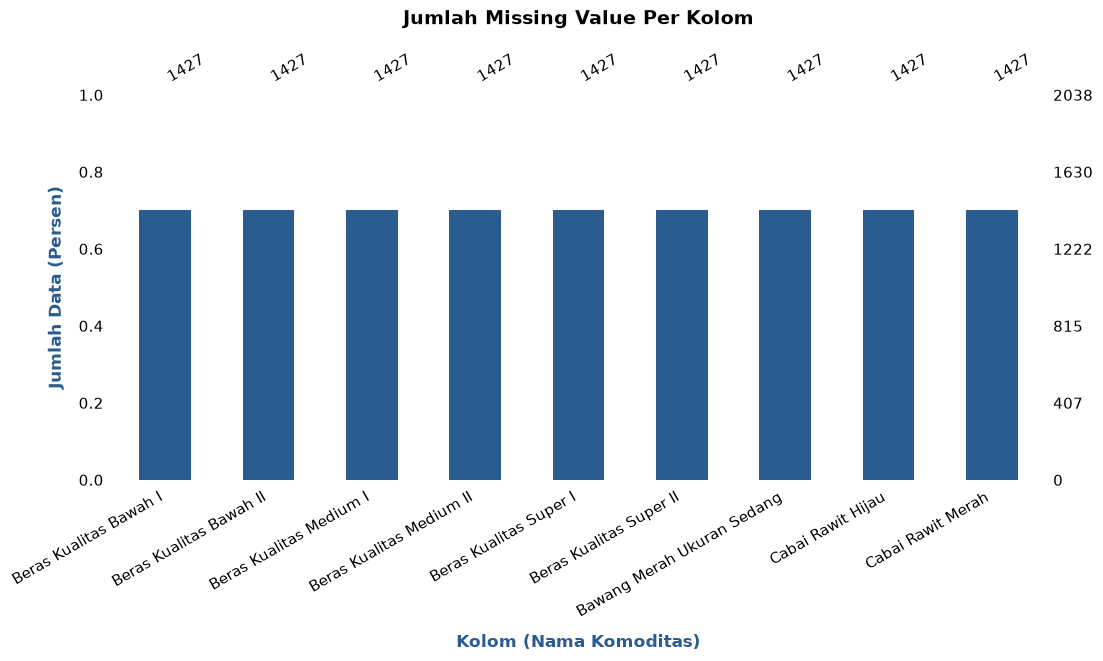

In [59]:
df_raw.isnull().sum()

ax = mgno.bar(
    df_raw,
    figsize=(12, 5),
    fontsize=11,
    labels=True,
    sort="ascending",
    p=True,
    color="#2b5c8f",
    label_rotation=30,
)

ax.set_title("Jumlah Missing Value Per Kolom", fontsize=14, fontweight="bold", pad=20)
ax.set_xlabel(
    "Kolom (Nama Komoditas)",
    fontsize=12,
    labelpad=10,
    fontweight="bold",
    color="#2b5c8f",
)
ax.set_ylabel(
    "Jumlah Data (Persen)", fontsize=12, labelpad=10, fontweight="bold", color="#2b5c8f"
)

### 2.7 Memeriksa Persentase Missing Value

Hitung persen nilai kosong tiap kolom.


In [60]:
percentages = (df_raw.isnull().sum() / len(df_raw)) * 100
print(percentages)

Beras Kualitas Bawah I        29.980373
Beras Kualitas Bawah II       29.980373
Beras Kualitas Medium I       29.980373
Beras Kualitas Medium II      29.980373
Beras Kualitas Super I        29.980373
Beras Kualitas Super II       29.980373
Bawang Merah Ukuran Sedang    29.980373
Cabai Rawit Hijau             29.980373
Cabai Rawit Merah             29.980373
dtype: float64


## 3. Penanganan Missing Value dengan Interpolasi

Isi gap pakai interpolasi waktu, jumlah baris tetap.


### 3.1 Interpolasi Berbasis Waktu

`method="time"` mengisi gap mengikuti jarak antar tanggal.


In [61]:
feature_interpolation = df_raw.interpolate(
    method="time", limit_direction="forward", axis=0
)

### 3.2 Menetapkan `df_cleaned` dan Memeriksa Missing Value

Hasil interpolasi disimpan ke `df_cleaned`, lalu dicek ulang.


In [62]:
df_cleaned = feature_interpolation
print(df_cleaned.isnull().sum())

Beras Kualitas Bawah I        0
Beras Kualitas Bawah II       0
Beras Kualitas Medium I       0
Beras Kualitas Medium II      0
Beras Kualitas Super I        0
Beras Kualitas Super II       0
Bawang Merah Ukuran Sedang    0
Cabai Rawit Hijau             0
Cabai Rawit Merah             0
dtype: int64


### 3.3 Memeriksa Persentase Missing Value Setelah Interpolasi

Pastikan persen missing sudah 0%.


In [63]:
feature_miss_value = df_cleaned.isnull().sum() * 100 / len(df_cleaned)
print(feature_miss_value)

Beras Kualitas Bawah I        0.0
Beras Kualitas Bawah II       0.0
Beras Kualitas Medium I       0.0
Beras Kualitas Medium II      0.0
Beras Kualitas Super I        0.0
Beras Kualitas Super II       0.0
Bawang Merah Ukuran Sedang    0.0
Cabai Rawit Hijau             0.0
Cabai Rawit Merah             0.0
dtype: float64


### 3.4 Visualisasi Missing Value Setelah Interpolasi (Heatmap)

Cek visual: nilai kosong sudah tidak ada.


Text(0, 0.5, 'Jumlah Data (Persen)')

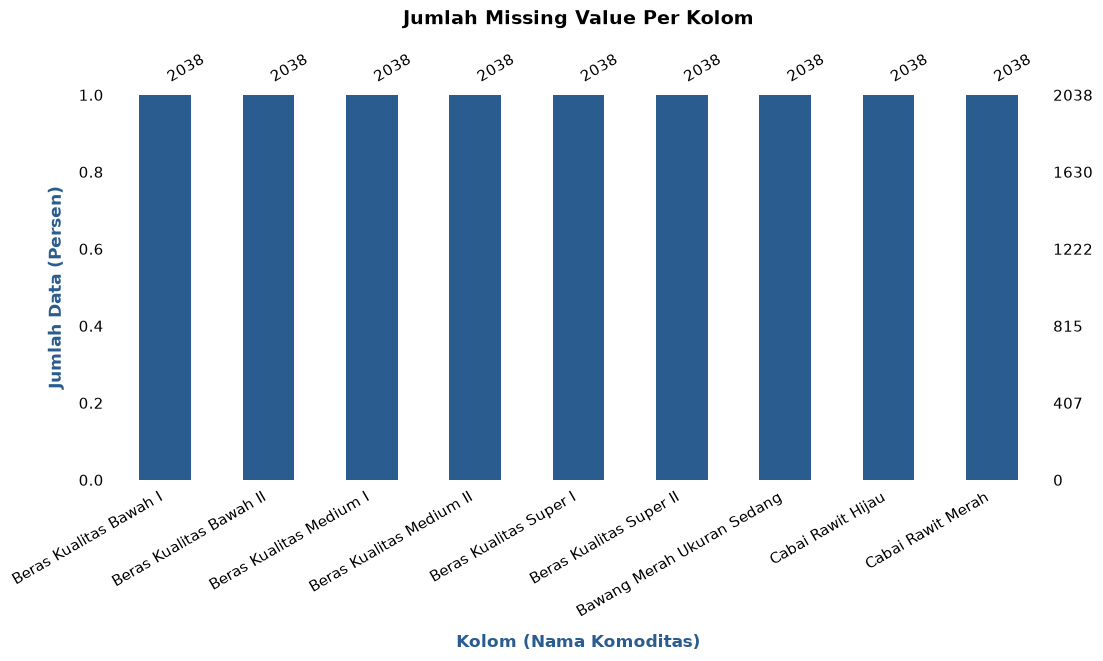

In [64]:
df_cleaned.isnull().sum()

ax = mgno.bar(
    df_cleaned,
    figsize=(12, 5),
    fontsize=11,
    labels=True,
    sort="ascending",
    p=True,
    color="#2b5c8f",
    label_rotation=30,
)

ax.set_title("Jumlah Missing Value Per Kolom", fontsize=14, fontweight="bold", pad=20)
ax.set_xlabel(
    "Kolom (Nama Komoditas)",
    fontsize=12,
    labelpad=10,
    fontweight="bold",
    color="#2b5c8f",
)
ax.set_ylabel(
    "Jumlah Data (Persen)", fontsize=12, labelpad=10, fontweight="bold", color="#2b5c8f"
)


## 4. Uji Stasioneritas (ADF Test)

ADF test: p-value < 0.05 berarti deret stasioner. Hasilnya jadi dasar detrending di bab 5.


### 4.1 Menentukan Daftar Kolom Komoditas

Simpan nama kolom komoditas ke `comodity_cols`.


In [65]:
comodity_cols = df_cleaned.columns.tolist()

### 4.2 ADF Test dengan Trend dan Konstanta (`regression="ct"`)

Uji stasioneritas dengan konstanta dan tren.


In [66]:
for col in comodity_cols:
    result = adfuller(
        df_cleaned[col].dropna(),
        maxlag=None,
        regression="ct",
        autolag="AIC",
        store=False,
        regresults=False,
        result_object=False,
    )

    print(f"ADF Statistic for {col}: {result[0]}")
    print(f"p-value for {col}: {result[1]}")
    if len(result) > 4:
        critical_values = result[4]
        print("Critical Values for: ")
        for key, value in critical_values.items():
            print(f"\t{key}: {value}")
    else:
        critical_values = {}
    status = "Stationary" if result[1] < 0.05 else "Non-Stationary"
    print(f"status : {status}")
    print("\n")

ADF Statistic for Beras Kualitas Bawah I: -1.1808364979181059
p-value for Beras Kualitas Bawah I: 0.9143563466248095
Critical Values for: 
	1%: -3.9632365697022998
	5%: -3.4126549567695705
	10%: -3.1283246497184187
status : Non-Stationary


ADF Statistic for Beras Kualitas Bawah II: -1.0090015757094497
p-value for Beras Kualitas Bawah II: 0.9428908749250067
Critical Values for: 
	1%: -3.9632321666575834
	5%: -3.412652823739877
	10%: -3.128323394200126
status : Non-Stationary


ADF Statistic for Beras Kualitas Medium I: -1.6561424262773168
p-value for Beras Kualitas Medium I: 0.7696836037691607
Critical Values for: 
	1%: -3.963278836113111
	5%: -3.4126754323752686
	10%: -3.1283367017897814
status : Non-Stationary


ADF Statistic for Beras Kualitas Medium II: -1.3309686501722213
p-value for Beras Kualitas Medium II: 0.8800549244101841
Critical Values for: 
	1%: -3.9632365697022998
	5%: -3.4126549567695705
	10%: -3.1283246497184187
status : Non-Stationary


ADF Statistic for Beras Kualita

### 4.3 Visualisasi Status Stasioneritas

Hijau = stasioner, oranye = belum stasioner.


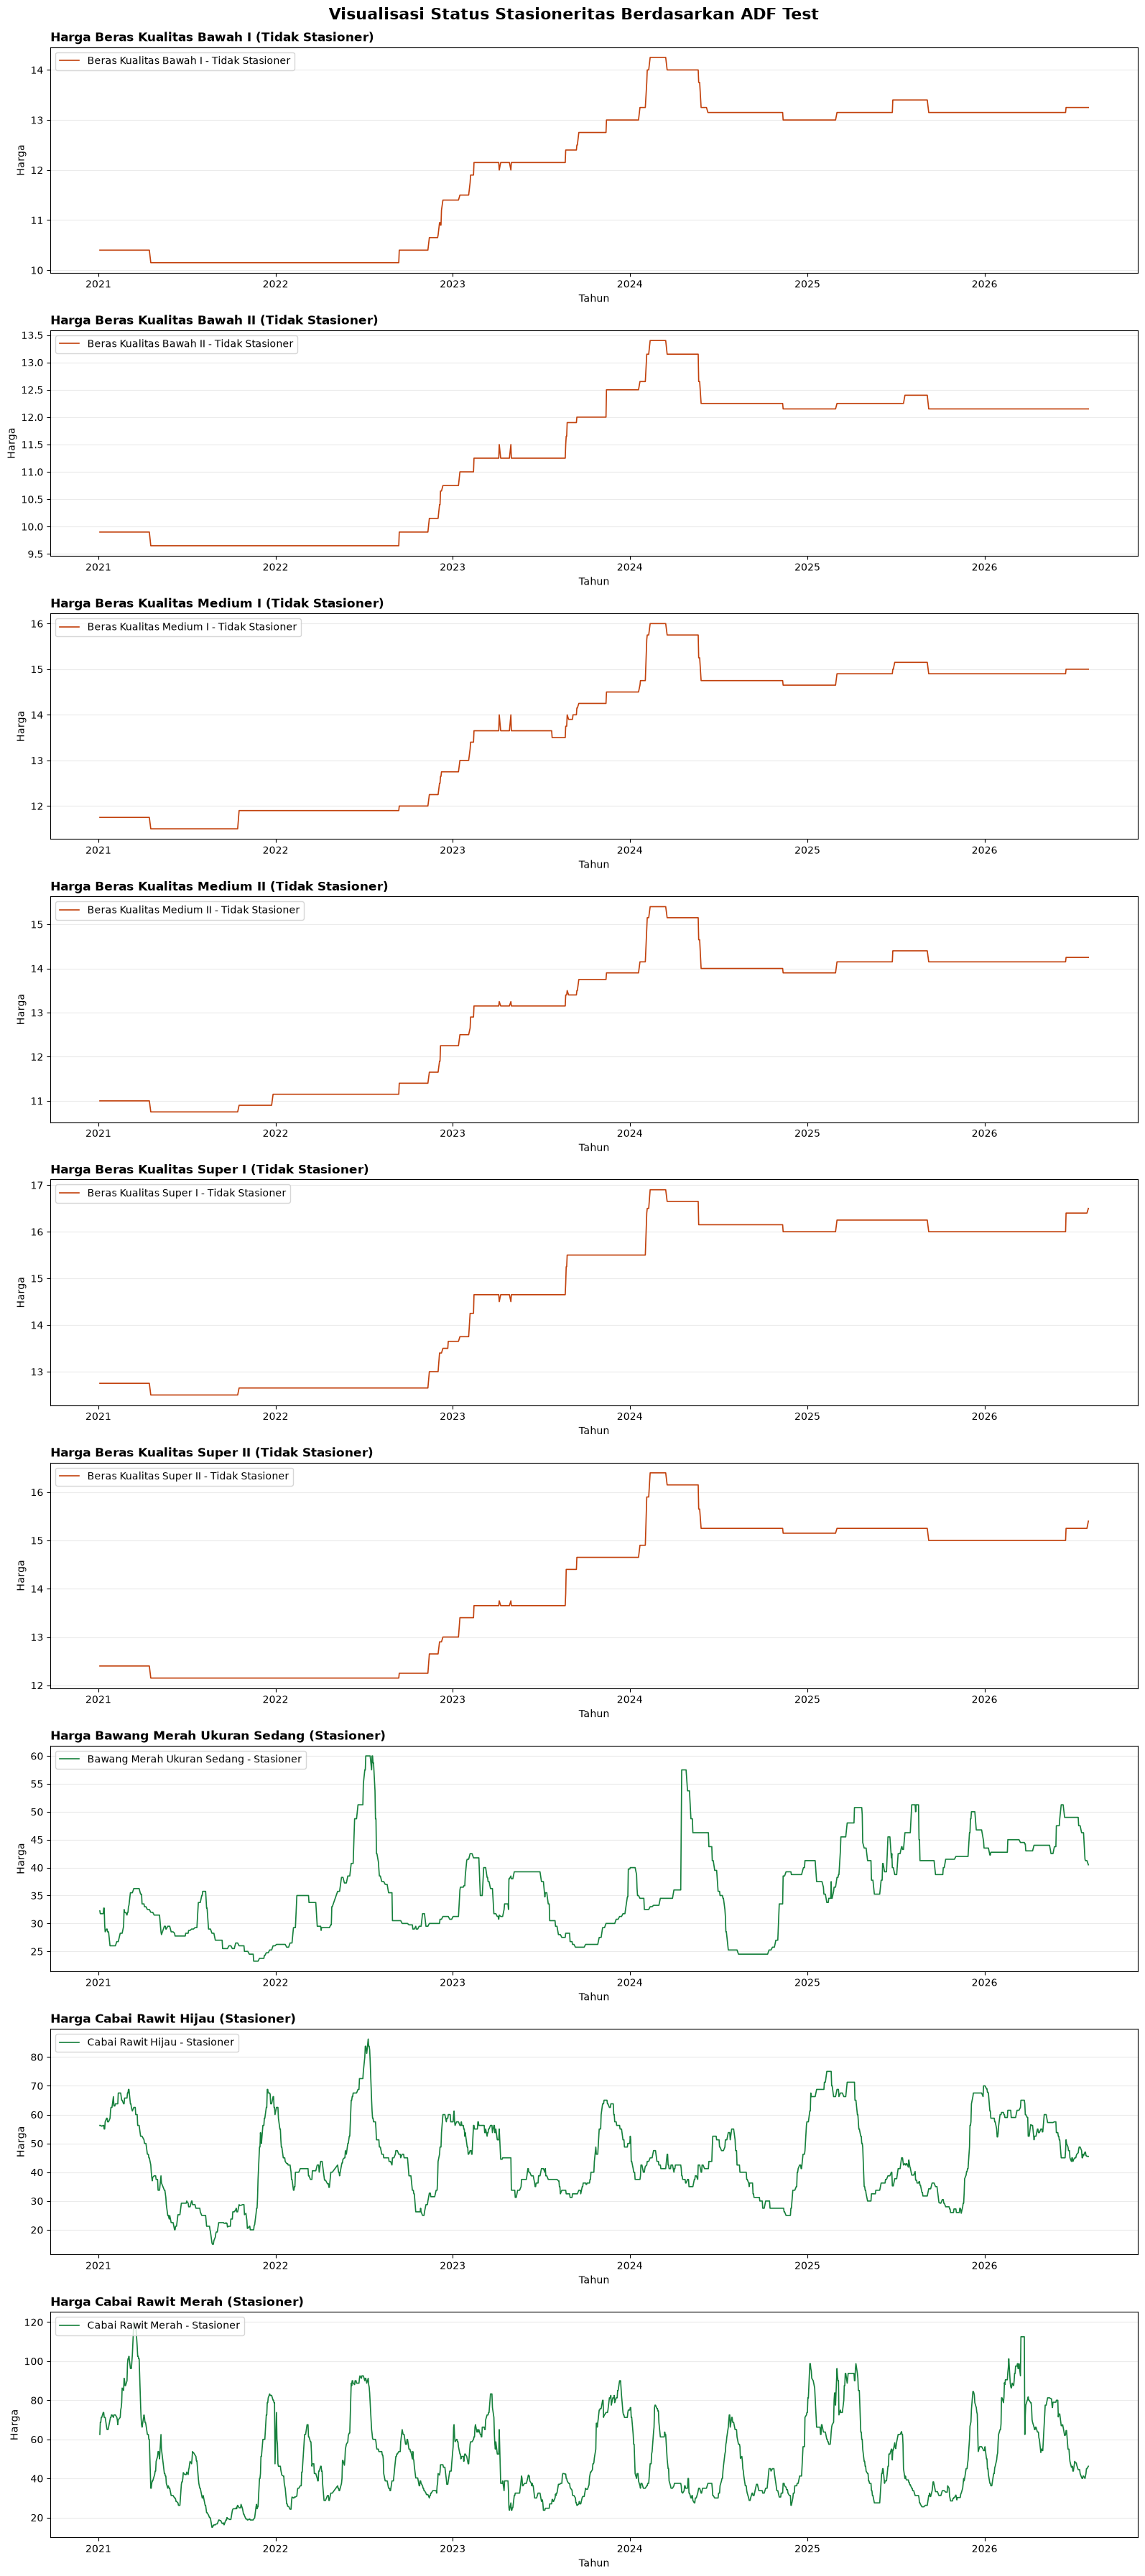

In [67]:
stasionery_status = {}
for col in comodity_cols:
    result = adfuller(
        df_cleaned[col].dropna(),
        maxlag=None,
        regression="ct",
        autolag="AIC",
        store=False,
        regresults=False,
        result_object=False,
    )
    stasionery_status[col] = "Stasioner" if result[1] < 0.05 else "Tidak Stasioner"

fig_size = (16, 4 * len(comodity_cols))

fig, axes = plt.subplots(
    nrows=len(comodity_cols),
    ncols=1,
    figsize=fig_size,
)

for ax, col in zip(axes, comodity_cols):
    status = stasionery_status[col]
    color = "#16803c" if status == "Stasioner" else "#c2410c"

    ax.plot(
        df_cleaned.index,
        df_cleaned[col],
        color=color,
        linewidth=1.2,
        label=f"{col} - {status}",
    )
    ax.set_title(f"Harga {col} ({status})", loc="left", fontsize=12, fontweight="bold")
    ax.set_ylabel("Harga")
    ax.set_xlabel("Tahun")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(loc="upper left")

fig.suptitle(
    "Visualisasi Status Stasioneritas Berdasarkan ADF Test",
    fontsize=16,
    fontweight="bold",
    y=0.995,
)
fig.subplots_adjust(hspace=0.6, top=0.97)
plt.tight_layout()

plt.show()

## 5. Detrending dan Deseasonalization dengan Dekomposisi MSTL

MSTL pecah harga jadi trend, musiman (7 & 365 hari), dan residual. Model jalan di residual.


### 5.1 Mendekomposisi Trend, Seasonal, dan Residual Setiap Komoditas

MSTL robust per komoditas; trend diaproksimasi regresi linier supaya bisa diekstrapolasi.


In [68]:
df_cleaned["time_index"] = np.arange(len(df_cleaned))
trend_model = {}
seasonal_model = {}

paras_mstl = {
    "periods": [7, 365],
    "stl_kwargs": {"robust": True},
}

for col in comodity_cols:
    mstl = MSTL(df_cleaned[col], **paras_mstl).fit()
    seasonal_model[col] = mstl

    df_cleaned[f"{col}_trend"] = mstl.trend.values
    df_cleaned[f"{col}_seasonal_weekly"] = mstl.seasonal["seasonal_7"].values
    df_cleaned[f"{col}_seasonal_yearly"] = mstl.seasonal["seasonal_365"].values
    df_cleaned[f"{col}_residual"] = mstl.resid.values

    trend_forecast = TrendForecaster(regressor=LinearRegression())
    trend_forecast.fit(df_cleaned[col].values)
    trend_model[col] = trend_forecast

### 5.1.1 Memeriksa Struktur `df_cleaned` Setelah Dekomposisi

Cek kolom baru: trend, seasonal, residual.


In [69]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2038 entries, 2021-01-04 to 2026-08-03
Freq: D
Data columns (total 46 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Beras Kualitas Bawah I                      2038 non-null   float64
 1   Beras Kualitas Bawah II                     2038 non-null   float64
 2   Beras Kualitas Medium I                     2038 non-null   float64
 3   Beras Kualitas Medium II                    2038 non-null   float64
 4   Beras Kualitas Super I                      2038 non-null   float64
 5   Beras Kualitas Super II                     2038 non-null   float64
 6   Bawang Merah Ukuran Sedang                  2038 non-null   float64
 7   Cabai Rawit Hijau                           2038 non-null   float64
 8   Cabai Rawit Merah                           2038 non-null   float64
 9   time_index                                  2038 non-null  

### 5.2 Menyimpan Model Trend dan Hasil MSTL

Simpan trend dan MSTL ke `.pkl` supaya tidak dekomposisi ulang.


In [70]:
jl.dump(trend_model, "models/trend_model.pkl")
jl.dump(seasonal_model, "models/seasonal_model.pkl")

['models/seasonal_model.pkl']

## 6. Feature Engineering (Fitur Lag dan Rolling)

Lag, rolling, dan kalender dibangun di dalam `ForecasterDirect` pada residual.


### 6.1 Fitur Lag, Statistik Rolling, dan Fitur Kalender

Lag 1/7/30, rolling 7 & 30 hari, plus kalender siklik. Tidak perlu susun `X`/`y` manual.


In [71]:
feature_builders = {}
horizons = [1, 7, 30]

for col in comodity_cols:
    feature_builders[col] = {}
    for h in horizons:
        feature_builders[col][h] = {}
        forecaster_setup = ForecasterDirect(
            estimator=lgb.LGBMRegressor(),
            steps=h,
            lags=[1, 7, 30],
        )
        window_features = RollingFeatures(
            stats=["mean", "mean", "std", "std", "min", "min", "max", "max"],
            window_sizes=[7, 30, 7, 30, 7, 30, 7, 30],
        )
        calendar_features = CalendarFeatures(
            features=[
                "day_of_year",
                "day_of_week",
                "day_of_month",
                "month",
            ],
            features_to_encode=["day_of_year", "day_of_month", "day_of_week", "month"],
            encoding="cyclical",
            max_values={
                "day_of_year": 365,
                "day_of_week": 6,
                "day_of_month": 31,
                "month": 12,
            },
        )
        save_forecaster(feature_builders, f"forecast/forecasters_{col}_h{h}.pkl")
        jl.dump(calendar_features, f"calender/calendar_features_{col}_h{h}.pkl")
        feature_builders[col][h] = {
            "window_features": window_features,
            "calendar_features": calendar_features,
        }


### 6.2 Melatih ForecasterDirect per Komoditas dan Horizon

`fit` residual untuk tiap komoditas pada horizon 1, 7, dan 30 hari.


In [72]:
horizons = [1, 7, 30]
forecasters_default = {}

for col in comodity_cols:
    forecasters_default[col] = {}
    for h in horizons:
        forecaster_default = ForecasterDirect(
            estimator=lgb.LGBMRegressor(force_col_wise=True),
            lags=[1, 7, 30],
            steps=h,
            window_features=window_features,
            calendar_features=calendar_features,
        )
        forecaster_default.fit(y=df_cleaned[f"{col}_residual"])
        forecasters_default[col][h] = forecaster_default


## 7. Pencarian Hyperparameter LightGBM dengan Genetic Algorithm

GA cari hyperparameter LightGBM per komoditas × horizon. Hasilnya dipakai di `ForecasterDirect`.


### 7.1 Fitness Function dan Konfigurasi GA (PyGAD)

Fitness = minus rata-rata RMSE. 5 generasi, populasi 10, 11 gen hyperparameter LightGBM.


In [73]:
def running_for_ga(y, steps, window_features, calendar_features):
    n_splits = 3
    fold_size = steps
    minimum_train_size = max(365, 2 * 30)
    first_train_size = len(y) - (n_splits * fold_size)

    if first_train_size < minimum_train_size:
        raise ValueError(
            f"Data training terlalu sedikit untuk horizon {steps}: "
            f"{first_train_size} baris."
        )

    def fitness_function(ga_instance, solution, solution_idx):
        params = {
            "num_leaves": int(solution[0]),
            "learning_rate": solution[1],
            "max_depth": int(solution[2]),
            "n_estimators": int(solution[3]),
            "min_child_samples": int(solution[4]),
            "subsample": solution[5],
            "colsample_bytree": solution[6],
            "min_child_weight": solution[7],
            "reg_alpha": solution[8],
            "reg_lambda": solution[9],
            "min_split_gain": solution[10],
            "bagging_freq": 1,
            "verbosity": -1,
        }

        rmse_scores = []

        try:
            for fold in range(n_splits):
                train_end = first_train_size + fold * fold_size
                test_end = train_end + fold_size
                y_train = y.iloc[:train_end]
                y_test = y.iloc[train_end:test_end]

                forecaster_cv = ForecasterDirect(
                    estimator=lgb.LGBMRegressor(**params),
                    steps=steps,
                    lags=[1, 7, 30],
                    window_features=window_features,
                    calendar_features=calendar_features,
                )
                forecaster_cv.fit(y=y_train)
                prediction = forecaster_cv.predict(steps=steps)

                rmse_scores.append(root_mean_squared_error(y_test, prediction))

            return -float(np.mean(rmse_scores))
        except Exception as error:
            print(f"Error for solution {solution_idx}: {error}")
            return -999.0

    gene_space = [
        {"low": 20, "high": 150},
        {"low": 0.01, "high": 0.3},
        {"low": 3, "high": 12},
        {"low": 50, "high": 400},
        {"low": 5, "high": 50},
        {"low": 0.5, "high": 1.0},
        {"low": 0.5, "high": 1.0},
        {"low": 1e-3, "high": 10},
        {"low": 0.0, "high": 1.0},
        {"low": 0.0, "high": 1.0},
        {"low": 0.0, "high": 1.0},
    ]

    def on_generation(ga_instance):
        best_fitness = np.max(ga_instance.last_generation_fitness)
        print(
            f"Generation {ga_instance.generations_completed}: "
            f"Best RMSE = {-best_fitness:.4f}"
        )

    genetic_algorithm_instance = pygad.GA(
        num_generations=5,
        sol_per_pop=10,
        num_parents_mating=5,
        num_genes=len(gene_space),
        fitness_func=fitness_function,
        gene_space=gene_space,
        on_generation=on_generation,
        parent_selection_type="tournament",
        crossover_type="single_point",
        crossover_probability=0.8,
        mutation_type="random",
        mutation_percent_genes=10,
        keep_elitism=2,
        random_seed=42,
    )

    genetic_algorithm_instance.run()
    return genetic_algorithm_instance.best_solution()

In [74]:
best_params_for_GA = {}
forecasters_ga = {}

for col in comodity_cols:
    residual = df_cleaned[f"{col}_residual"]
    best_params_for_GA[col] = {}
    forecasters_ga[col] = {}

    for h in horizons:
        best_solution, best_solution_fitness, best_solution_idx = running_for_ga(
            y=residual,
            steps=h,
            window_features=window_features,
            calendar_features=calendar_features,
        )

        params = {
            "num_leaves": int(best_solution[0]),
            "learning_rate": best_solution[1],
            "max_depth": int(best_solution[2]),
            "n_estimators": int(best_solution[3]),
            "min_child_samples": int(best_solution[4]),
            "subsample": best_solution[5],
            "colsample_bytree": best_solution[6],
            "min_child_weight": best_solution[7],
            "reg_alpha": best_solution[8],
            "reg_lambda": best_solution[9],
            "min_split_gain": best_solution[10],
            "bagging_freq": 1,
            "verbosity": -1,
        }

        best_params_for_GA[col][h] = {
            "params": params,
            "fitness": best_solution_fitness,
            "solution_index": best_solution_idx,
        }

        forecaster_ga = ForecasterDirect(
            estimator=lgb.LGBMRegressor(**params),
            steps=h,
            lags=[1, 7, 30],
            window_features=window_features,
            calendar_features=calendar_features,
        )
        forecaster_ga.fit(y=residual)
        forecasters_ga[col][h] = forecaster_ga
        save_forecaster(forecasters_ga, f"forecast_ga/forecasters_ga_{col}_h{h}.pkl")


╭─────────────────────────────── IgnoredArgumentWarning ───────────────────────────────╮
│ The number of bins has been reduced from 10 to 9 due to duplicated edges caused by   │
│ repeated predicted values.                                                           │
│                                                                                      │
│ Category : skforecast.exceptions.IgnoredArgumentWarning                              │
│ Location : d:\PR DAN SEBAGAINYA TENTANG KAMPUS\SEMESTER 7 SKIRPSI\PROGRAM            │
│ SKRIPSI\.venv\Lib\site-packages\skforecast\preprocessing\_preprocessing.py:2340      │
│ Suppress : warnings.simplefilter('ignore', category=IgnoredArgumentWarning)          │
╰──────────────────────────────────────────────────────────────────────────────────────╯

Generation 1: Best RMSE = 0.0001


╭─────────────────────────────── IgnoredArgumentWarning ───────────────────────────────╮
│ The number of bins has been reduced from 10 to 9 due to duplicated edges caused by   │
│ repeated predicted values.                                                           │
│                                                                                      │
│ Category : skforecast.exceptions.IgnoredArgumentWarning                              │
│ Location : d:\PR DAN SEBAGAINYA TENTANG KAMPUS\SEMESTER 7 SKIRPSI\PROGRAM            │
│ SKRIPSI\.venv\Lib\site-packages\skforecast\preprocessing\_preprocessing.py:2340      │
│ Suppress : warnings.simplefilter('ignore', category=IgnoredArgumentWarning)          │
╰──────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────── IgnoredArgumentWarning ───────────────────────────────╮
│ The number of bins has been reduced from 10 to 9 due to duplicated edges caused by   │
│ repeated predicted values.                                                           │
│                                                                                      │
│ Category : skforecast.exceptions.IgnoredArgumentWarning                              │
│ Location : d:\PR DAN SEBAGAINYA TENTANG KAMPUS\SEMESTER 7 SKIRPSI\PROGRAM            │
│ SKRIPSI\.venv\Lib\site-packages\skforecast\preprocessing\_preprocessing.py:2340      │
│ Suppress : warnings.simplefilter('ignore', category=IgnoredArgumentWarning)          │
╰──────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────── IgnoredArgumentWarning ───────────────────────────────╮
│ The number of bins has been reduced from 10 to 9 due to duplicated edges caused by   │
│ repeated predicted values.                                                           │
│                                                                                      │
│ Category : skforecast.exceptions.IgnoredArgumentWarning                              │
│ Location : d:\PR DAN SEBAGAINYA TENTANG KAMPUS\SEMESTER 7 SKIRPSI\PROGRAM            │
│ SKRIPSI\.venv\Lib\site-packages\skforecast\preprocessing\_preprocessing.py:2340      │
│ Suppress : warnings.simplefilter('ignore', category=IgnoredArgumentWarning)          │
╰──────────────────────────────────────────────────────────────────────────────────────╯

...

╭─────────────────────────────── IgnoredArgumentWarning ───────────────────────────────╮
│ The number of bins has been reduced from 10 to 9 due to duplicated edges caused by   │
│ repeated predicted values.                                                           │
│                                                                                      │
│ Category : skforecast.exceptions.IgnoredArgumentWarning                              │
│ Location : d:\PR DAN SEBAGAINYA TENTANG KAMPUS\SEMESTER 7 SKIRPSI\PROGRAM            │
│ SKRIPSI\.venv\Lib\site-packages\skforecast\preprocessing\_preprocessing.py:2340      │
│ Suppress : warnings.simplefilter('ignore', category=IgnoredArgumentWarning)          │
╰──────────────────────────────────────────────────────────────────────────────────────╯

Generation 5: Best RMSE = 0.0354


╭─────────────────────────────── IgnoredArgumentWarning ───────────────────────────────╮
│ The number of bins has been reduced from 10 to 9 due to duplicated edges caused by   │
│ repeated predicted values.                                                           │
│                                                                                      │
│ Category : skforecast.exceptions.IgnoredArgumentWarning                              │
│ Location : d:\PR DAN SEBAGAINYA TENTANG KAMPUS\SEMESTER 7 SKIRPSI\PROGRAM            │
│ SKRIPSI\.venv\Lib\site-packages\skforecast\preprocessing\_preprocessing.py:2340      │
│ Suppress : warnings.simplefilter('ignore', category=IgnoredArgumentWarning)          │
╰──────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────── IgnoredArgumentWarning ───────────────────────────────╮
│ The number of bins has been reduced from 10 to 9 due to duplicated edges caused by   │
│ repeated predicted values.                                                           │
│                                                                                      │
│ Category : skforecast.exceptions.IgnoredArgumentWarning                              │
│ Location : d:\PR DAN SEBAGAINYA TENTANG KAMPUS\SEMESTER 7 SKIRPSI\PROGRAM            │
│ SKRIPSI\.venv\Lib\site-packages\skforecast\preprocessing\_preprocessing.py:2340      │
│ Suppress : warnings.simplefilter('ignore', category=IgnoredArgumentWarning)          │
╰──────────────────────────────────────────────────────────────────────────────────────╯

Generation 1: Best RMSE = 0.0235
Generation 2: Best RMSE = 0.0235
Generation 3: Best RMSE = 0.0235
Generation 4: Best RMSE = 0.0229
Generation 5: Best RMSE = 0.0229
Generation 1: Best RMSE = 0.0372
Generation 2: Best RMSE = 0.0359
Generation 3: Best RMSE = 0.0351
Generation 4: Best RMSE = 0.0351
Generation 5: Best RMSE = 0.0351
Generation 1: Best RMSE = 1.1178
Generation 2: Best RMSE = 1.1178
Generation 3: Best RMSE = 1.1178
Generation 4: Best RMSE = 1.1178
Generation 5: Best RMSE = 1.1178
Generation 1: Best RMSE = 0.8191
Generation 2: Best RMSE = 0.8191
Generation 3: Best RMSE = 0.8184
Generation 4: Best RMSE = 0.8184
Generation 5: Best RMSE = 0.8012
Generation 1: Best RMSE = 1.6289
Generation 2: Best RMSE = 1.6289
Generation 3: Best RMSE = 1.4231
Generation 4: Best RMSE = 1.4231
Generation 5: Best RMSE = 1.4231
Generation 1: Best RMSE = 0.0719
Generation 2: Best RMSE = 0.0719
Generation 3: Best RMSE = 0.0719
Generation 4: Best RMSE = 0.0719
Generation 5: Best RMSE = 0.0719
Generation

### 7.2 Menampilkan Hyperparameter Terbaik per Komoditas dan Horizon

Tampilkan params GA terbaik untuk horizon 1, 7, dan 30 hari.


In [75]:
for commodity, params_h in best_params_for_GA.items():
    print("\n" + "=" * 72)
    print(f"Nama Komoditas: {commodity}")
    print("=" * 72)

    for h in horizons:
        result = params_h[h]
        parameters = result["params"]
        print(f"\nBest parameters for horizon {h}:")
        for key, value in parameters.items():
            if isinstance(value, float):
                print(f"{key:20s}: {value:.6f}")
            else:
                print(f"{key:20s}: {value}")



Nama Komoditas: Beras Kualitas Bawah I

Best parameters for horizon 1:
num_leaves          : 63
learning_rate       : 0.202131
max_depth           : 5
n_estimators        : 232
min_child_samples   : 29
subsample           : 0.592427
colsample_bytree    : 0.984792
min_child_weight    : 3.988810
reg_alpha           : 0.939499
reg_lambda          : 0.894827
min_split_gain      : 0.597900
bagging_freq        : 1
verbosity           : -1

Best parameters for horizon 7:
num_leaves          : 23
learning_rate       : 0.146942
max_depth           : 4
n_estimators        : 389
min_child_samples   : 14
subsample           : 0.780639
colsample_bytree    : 0.885484
min_child_weight    : 3.988810
reg_alpha           : 0.522733
reg_lambda          : 0.427541
min_split_gain      : 0.025419
bagging_freq        : 1
verbosity           : -1

Best parameters for horizon 30:
num_leaves          : 110
learning_rate       : 0.202131
max_depth           : 5
n_estimators        : 389
min_child_samples   : 39

### 7.4 Menyimpan Hasil Hyperparameter

Simpan params GA ke `.pkl` supaya tidak search ulang.


In [76]:
jl.dump(best_params_for_GA, "models/genetic_algorithm_parameters.pkl")

['models/genetic_algorithm_parameters.pkl']

## 8. Evaluasi Residual pada Data Test

Membagi residual jadi train/test, melatih ulang `ForecasterDirect` di train dengan parameter GA, lalu memprediksi dan menilai residual di periode test.


### 8.1 Membagi Residual Menjadi Train dan Test

30 baris terakhir jadi test, sisanya train. Residual tiap komoditas dipotong dengan `TemporalTrainTestSplitter`.


In [77]:
splitter = TemporalTrainTestSplitter(train_size=None, test_size=30, anchor="start")

for col in comodity_cols:
    y = df_cleaned[f"{col}_residual"]
    for train_idx, test_idx in splitter.split(y):
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

### 8.2 Melatih ForecasterDirect pada Residual Train

`ForecasterDirect` dibuat ulang dengan hyperparameter GA, lalu di-`fit` hanya pada `y_train`.


In [ ]:
forecaster_eval = ForecasterDirect(
    estimator=lgb.LGBMRegressor(**best_params_for_GA[col][h]["params"]),
    steps=h,
    lags=[1, 7, 30],
    window_features=window_features,
    calendar_features=calendar_features,
)

forecaster_eval.fit(y_train)

### 8.3 Prediksi Residual pada Data Test

Prediksi residual h hari ke depan dari ujung data train.


In [92]:
prediction = forecaster_eval.predict(steps=h)

### 8.4 Evaluasi Residual (MAE, RMSE, R2)

Membandingkan residual prediksi dengan residual aktual di test.


In [93]:
mae = mean_absolute_error(y_test, prediction)
rmse = root_mean_squared_error(y_test, prediction)
mape = mean_absolute_percentage_error(y_test, prediction)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE: 4.04
RMSE: 5.08
MAPE: 1.26%
